In [21]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [22]:
PROJECT_ROOT = Path("..").resolve()
WORKLOAD = "tinymlp"

RUNS_DIR = PROJECT_ROOT / "results" / WORKLOAD
assert RUNS_DIR.exists(), f"Can't find {RUNS_DIR}. Did runs finish and write results?"

print("Using runs dir:", RUNS_DIR)
print("Predictor subdirs:", [p.name for p in RUNS_DIR.iterdir() if p.is_dir()])

Using runs dir: /home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp
Predictor subdirs: ['TAGE', 'BiModeBP', 'GshareBP']


In [23]:
STAT_LINE = re.compile(r"^([A-Za-z0-9_.:]+)\s+([-+0-9.eE]+)\s+#")

def load_stats(stats_path: Path) -> dict:
    stats = {}
    with stats_path.open() as f:
        for line in f:
            m = STAT_LINE.match(line.strip())
            if not m:
                continue
            k, v = m.group(1), m.group(2)
            try:
                stats[k] = float(v)
            except ValueError:
                pass
    return stats

In [24]:
def discover_runs(results_dir: Path):
    """
    Expected:
      results/<workload>/<predictor>/stats.txt
    """
    runs = []
    for workload_dir in sorted(results_dir.iterdir()):
        if not workload_dir.is_dir():
            continue
        for pred_dir in sorted(workload_dir.iterdir()):
            if not pred_dir.is_dir():
                continue
            stats_path = pred_dir / "stats.txt"
            if stats_path.exists() and stats_path.stat().st_size > 0:
                runs.append((workload_dir.name, pred_dir.name, pred_dir, stats_path))
    return runs

runs = discover_runs(RESULTS_DIR)
print("Runs found:", len(runs))
runs[:5]

Runs found: 6


[('hello',
  'BiModeBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/BiModeBP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/BiModeBP/stats.txt')),
 ('hello',
  'GshareBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/GshareBP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/GshareBP/stats.txt')),
 ('hello',
  'TAGE',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/TAGE'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/hello/TAGE/stats.txt')),
 ('tinymlp',
  'BiModeBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/BiModeBP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/BiModeBP/stats.txt')),
 ('tinymlp',
  'GshareBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/GshareBP'),
  Pos

In [25]:
def pick_first(stats: dict, keys: list[str]):
    for k in keys:
        if k in stats:
            return k, stats[k]
    return None, None

def find_branch_counters(stats: dict):
    """
    Returns:
      (lookups_key, lookups_val, mispred_key, mispred_val)

    Different predictors expose different stat names. We try multiple common names
    and then fall back to keyword matching under branchPred.
    """
    lookup_candidates = [
        "system.cpu.branchPred.lookups",
        "system.cpu.branchPred.condLookups",
        "system.cpu.branchPred.condBranches",
        "system.cpu.branchPred.condPredicted",
    ]
    mispred_candidates = [
        "system.cpu.branchPred.incorrect",
        "system.cpu.branchPred.condIncorrect",
        "system.cpu.branchPred.condMispredicted",
        "system.cpu.branchPred.condWrong",
        "system.cpu.branchPred.mispredictions",
    ]

    lk_key, lk = pick_first(stats, lookup_candidates)
    mp_key, mp = pick_first(stats, mispred_candidates)

    # Fallback for lookups
    if lk is None:
        for k, v in stats.items():
            kl = k.lower()
            if "branchpred" in kl and ("lookup" in kl or "predicted" in kl):
                lk_key, lk = k, v
                break

    # Fallback for mispreds
    if mp is None:
        for k, v in stats.items():
            kl = k.lower()
            if "branchpred" in kl and ("misp" in kl or "incorrect" in kl or "wrong" in kl):
                mp_key, mp = k, v
                break

    return lk_key, lk, mp_key, mp

In [26]:
rows = []

predictor_dirs = sorted([p for p in RUNS_DIR.iterdir() if p.is_dir()])

for pdir in predictor_dirs:
    stats_path = pdir / "stats.txt"
    if not stats_path.exists() or stats_path.stat().st_size == 0:
        print("Skipping (missing/empty stats):", pdir)
        continue

    stats = load_stats(stats_path)

    ipc = stats.get("system.cpu.ipc", None)
    cpi = stats.get("system.cpu.cpi", None)
    simInsts = stats.get("simInsts", None)
    simTicks = stats.get("simTicks", None)
    hostSeconds = stats.get("hostSeconds", None)

    lk_key, lk, mp_key, mp = find_branch_counters(stats)

    mispred_rate = None
    if lk is not None and mp is not None and lk > 0:
        mispred_rate = mp / lk

    rows.append({
        "predictor": pdir.name,
        "ipc": ipc,
        "cpi": cpi,
        "simInsts": simInsts,
        "simTicks": simTicks,
        "hostSeconds": hostSeconds,
        "bp_lookups": lk,
        "bp_mispreds": mp,
        "mispred_rate": mispred_rate,
        "bp_lookup_stat": lk_key,
        "bp_mispred_stat": mp_key,
        "stats_path": str(stats_path.relative_to(PROJECT_ROOT)),
    })

df = pd.DataFrame(rows).sort_values("predictor").reset_index(drop=True)
df

,predictor,ipc,cpi,simInsts,simTicks,hostSeconds,bp_lookups,bp_mispreds,mispred_rate,bp_lookup_stat,bp_mispred_stat,stats_path
0,BiModeBP,1.919220,0.521045,10000000.0,2.605224e+09,36.19,6160826.0,238361.0,0.038690,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,results/tinymlp/BiModeBP/stats.txt
1,GshareBP,1.007359,0.992695,10000001.0,4.963473e+09,68.75,15542798.0,684250.0,0.044024,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,results/tinymlp/GshareBP/stats.txt
2,TAGE,3.661019,0.273148,10000003.0,1.365740e+09,19.78,2702055.0,4871.0,0.001803,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,results/tinymlp/TAGE/stats.txt


In [27]:
df.shape

(3, 12)

In [28]:
df[["predictor","mispred_rate","bp_lookup_stat","bp_mispred_stat"]]

,predictor,mispred_rate,bp_lookup_stat,bp_mispred_stat
0,BiModeBP,0.038690,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect
1,GshareBP,0.044024,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect
2,TAGE,0.001803,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect


In [29]:
BASELINE = "BiModeBP"
base_ipc = df.loc[df["predictor"] == BASELINE, "ipc"].iloc[0]

df2 = df.copy()
df2["speedup_vs_bimode"] = df2["ipc"] / base_ipc
df2.sort_values("speedup_vs_bimode", ascending=False)[["predictor","ipc","speedup_vs_bimode","mispred_rate","cpi"]]

,predictor,ipc,speedup_vs_bimode,mispred_rate,cpi
2,TAGE,3.661019,1.907556,0.001803,0.273148
0,BiModeBP,1.919220,1.000000,0.038690,0.521045
1,GshareBP,1.007359,0.524879,0.044024,0.992695


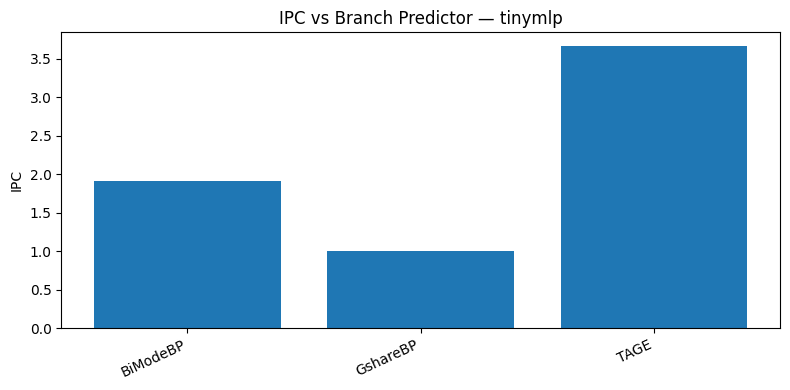

In [30]:
plt.figure(figsize=(8,4))
plt.bar(df["predictor"], df["ipc"])
plt.title(f"IPC vs Branch Predictor — {WORKLOAD}")
plt.ylabel("IPC")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

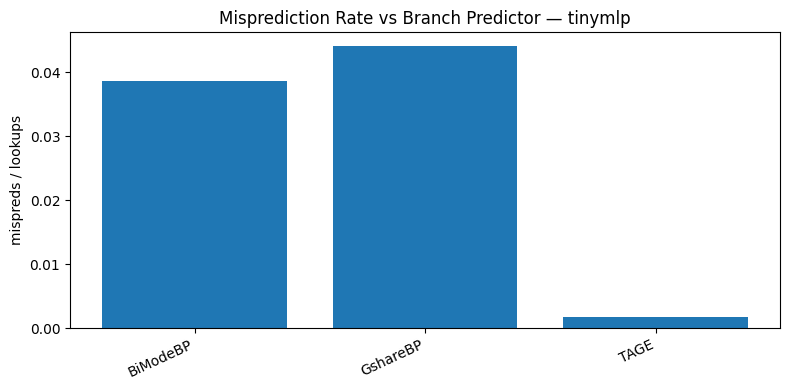

In [31]:
plt.figure(figsize=(8,4))
plt.bar(df["predictor"], df["mispred_rate"])
plt.title(f"Misprediction Rate vs Branch Predictor — {WORKLOAD}")
plt.ylabel("mispreds / lookups")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [32]:
out_csv = PROJECT_ROOT / "results" / f"{WORKLOAD}_predictor_comparison.csv"
df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)

Wrote: /home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp_predictor_comparison.csv


In [33]:
df[["predictor","bp_lookup_stat","bp_mispred_stat","bp_lookups","bp_mispreds","mispred_rate","ipc"]]

,predictor,bp_lookup_stat,bp_mispred_stat,bp_lookups,bp_mispreds,mispred_rate,ipc
0,BiModeBP,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,6160826.0,238361.0,0.038690,1.919220
1,GshareBP,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,15542798.0,684250.0,0.044024,1.007359
2,TAGE,system.cpu.branchPred.condPredicted,system.cpu.branchPred.condIncorrect,2702055.0,4871.0,0.001803,3.661019
